# Database: Student Exam Results

## Imports

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import bartlett
from scipy.stats import spearmanr
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
import plotly.express as px
sns.set(style="whitegrid", palette="muted")

## Funciones auxiliares

In [33]:
# Función que separa las variables de entrada y salida
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [34]:
# Transformador diseñado para escalar de manera sencilla únicamente unas columnas seleccionadas con MinMaxScaler
class CustomScalerMinMax(BaseEstimator, TransformerMixin):
    def __init__(self, attributes):
        self.attributes = attributes
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        X_copy = X.copy()
        scale_attrs = X_copy[self.attributes]
        minmax_scaler = MinMaxScaler()
        X_scaled = minmax_scaler.fit_transform(scale_attrs)
        X_scaled = pd.DataFrame(X_scaled, columns=self.attributes, index=X_copy.index)
        for attr in self.attributes:
            X_copy[attr] = X_scaled[attr]
        return X_copy

## 1. Lectura del conjunto de datos

In [35]:
df = pd.read_csv("Student_Exam_Results - Student_Exam_Results.csv")

## 2. Visualización del conjunto de datos

In [36]:
# Se eliminan las columnas Total y Div
df1 = df.drop(["Total","Div"], axis=1)

In [37]:
# Dimension del conjunto de datos
df1.shape

(1000, 7)

In [38]:
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Hindi      1000 non-null   int64
 1   English    1000 non-null   int64
 2   Science    1000 non-null   int64
 3   Maths      1000 non-null   int64
 4   History    1000 non-null   int64
 5   Geograpgy  1000 non-null   int64
 6   Results    1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


,Hindi,English,Science,Maths,History,Geograpgy,Results
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,51.645000,50.110000,49.440000,49.553000,49.03400,50.028000,0.350000
std,29.471912,28.048505,28.921114,28.632447,28.76975,28.710268,0.477208
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,26.000000,26.000000,25.000000,25.750000,24.00000,26.000000,0.000000
50%,53.000000,50.500000,50.000000,49.000000,49.00000,49.000000,0.000000
75%,77.000000,75.000000,73.250000,74.000000,73.25000,75.000000,1.000000
max,99.000000,99.000000,99.000000,99.000000,99.00000,99.000000,1.000000


In [39]:
df1.head()

,Hindi,English,Science,Maths,History,Geograpgy,Results
0,65,10,59,3,71,37,0
1,94,56,4,67,91,50,1
2,7,85,76,99,60,25,0
3,88,46,59,94,52,38,1
4,39,81,37,38,6,54,1


In [40]:
# Se verifica si hay valores nulos
df1.isna().sum()

Hindi        0
English      0
Science      0
Maths        0
History      0
Geograpgy    0
Results      0
dtype: int64

In [41]:
# Se tienen 650 reprobados y 350 aprobados
df1["Results"].value_counts()

Results
0    650
1    350
Name: count, dtype: int64

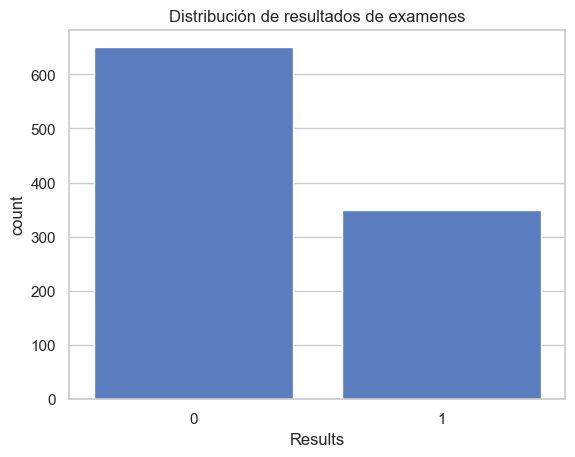

In [42]:
sns.countplot(x="Results", data=df1)
plt.title("Distribución de resultados de examenes")
plt.show()

## 3. Histogramas

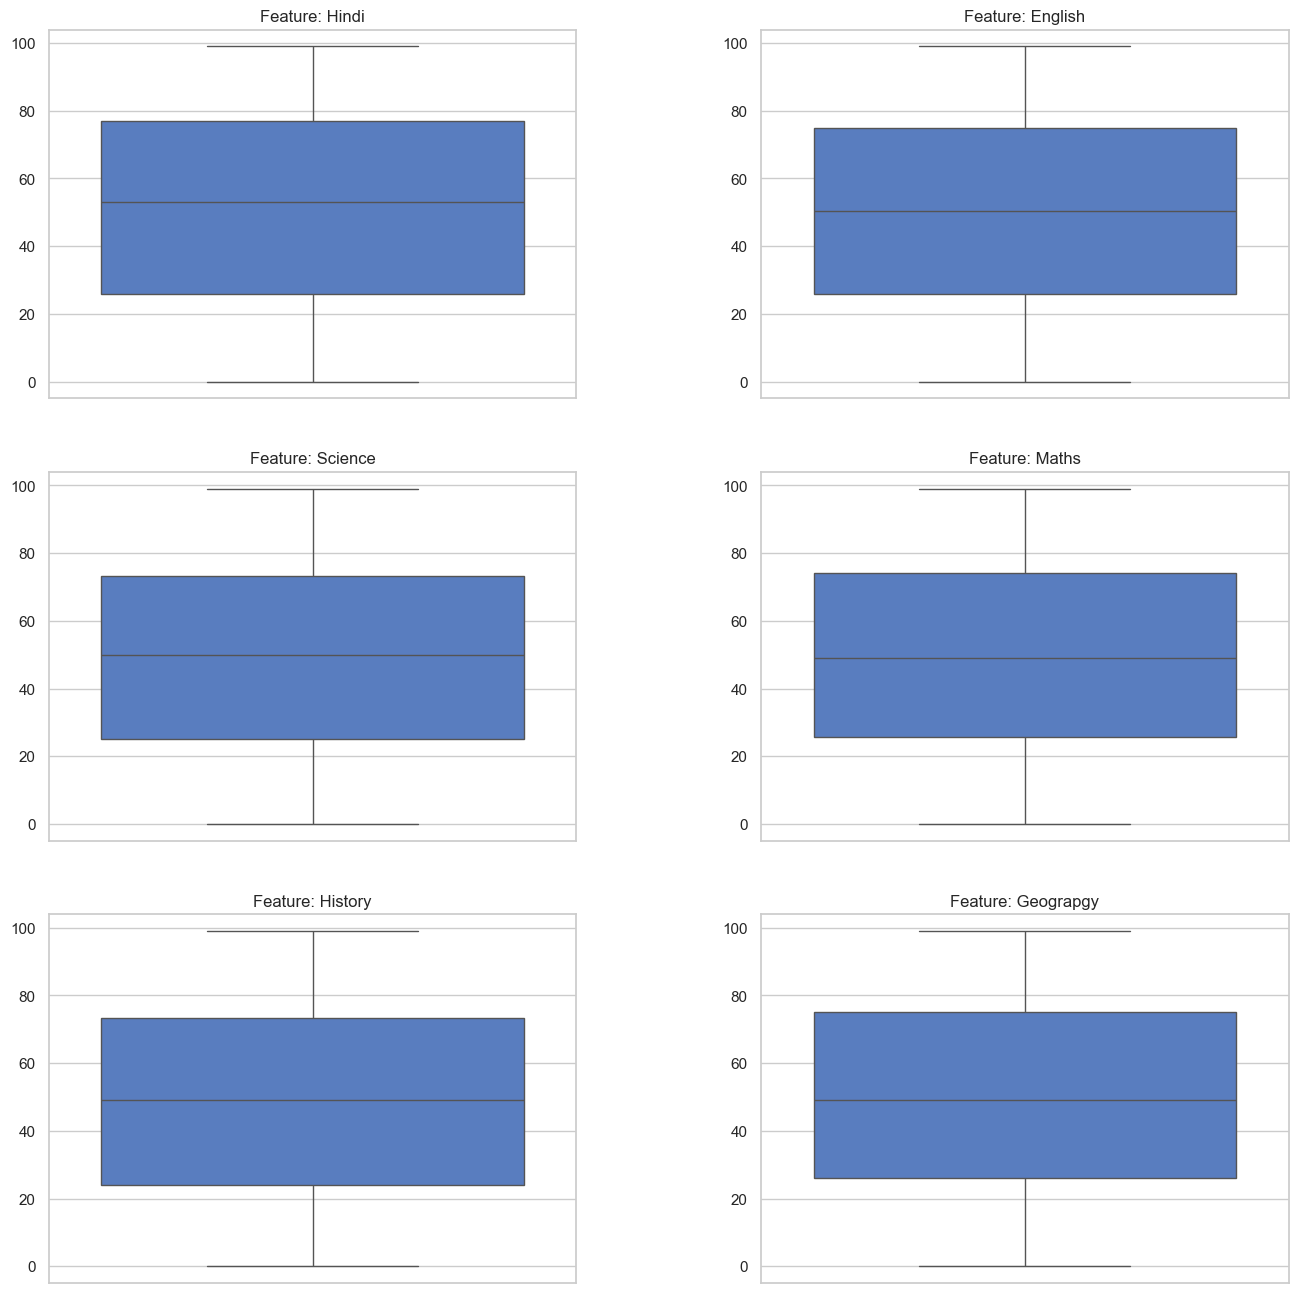

In [43]:
# Boxplots
features = df1.drop(["Results"], axis=1)

plt.figure(figsize=(16, 45))
gs = gridspec.GridSpec(8, 2)
gs.update(wspace=0.35, hspace=0.2)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    # Boxplots por clase
    sns.boxplot(data=df1[f], ax=ax)
    ax.set_ylabel('')
    ax.set_title(f"Feature: {f}")

plt.show()

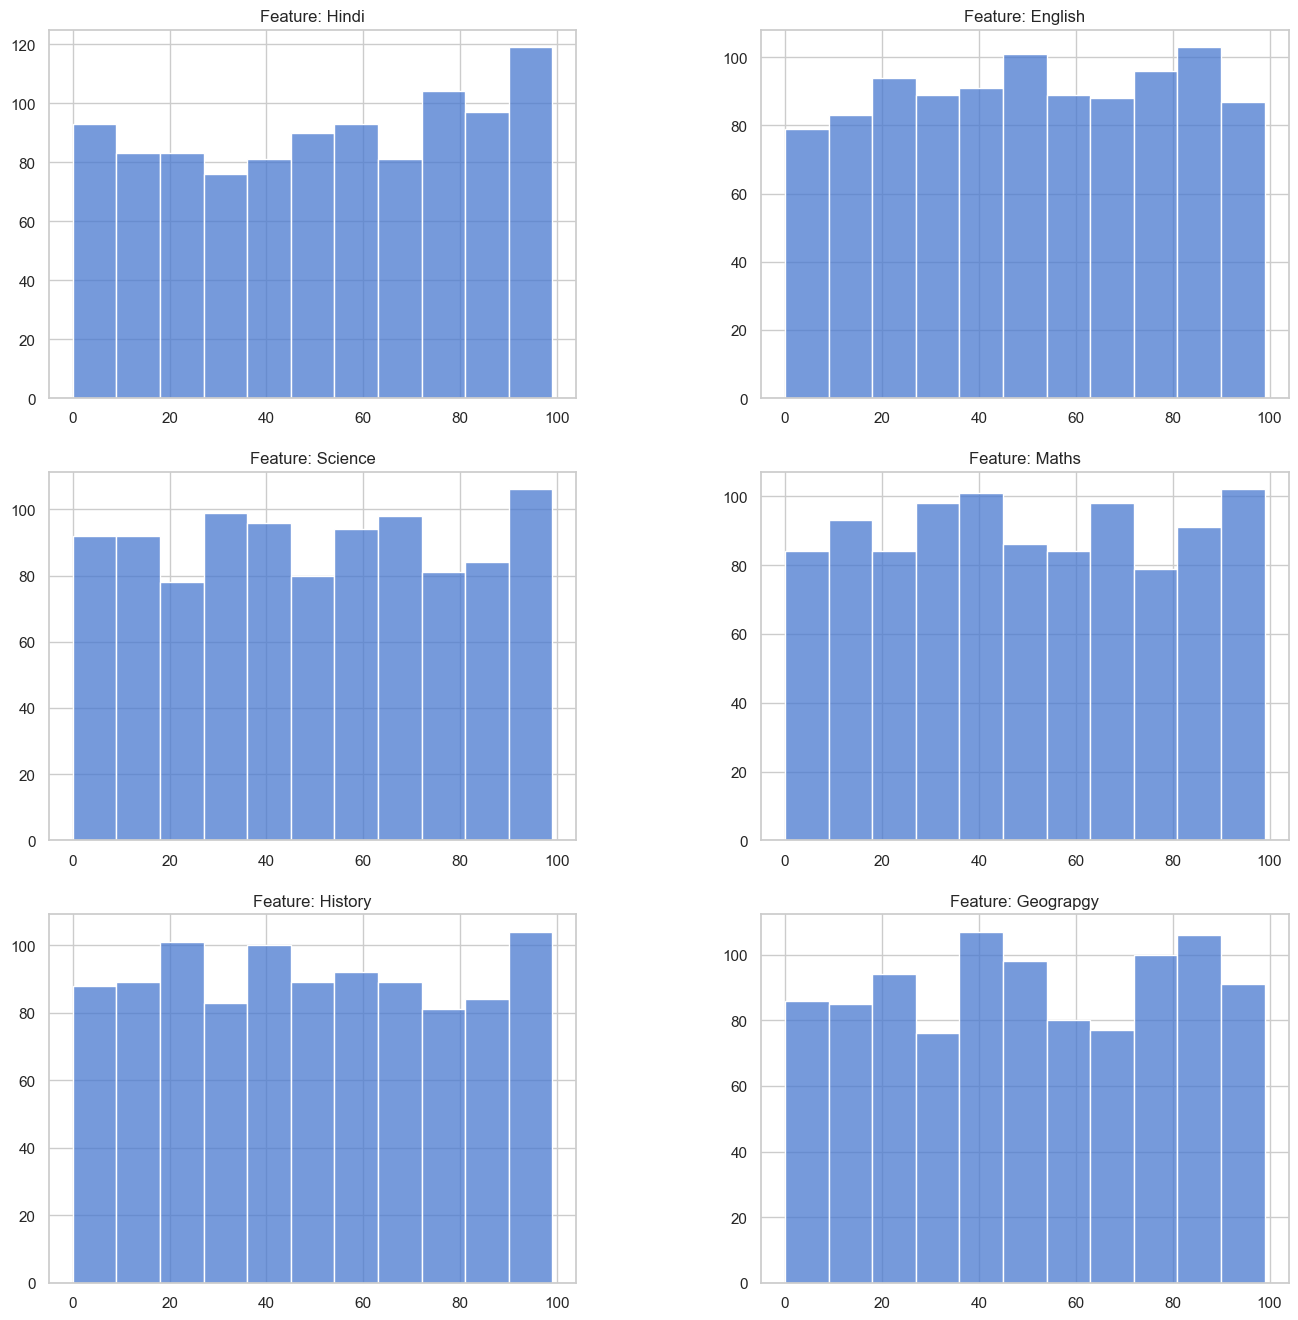

In [44]:
# Histogramas
features = df1.drop(["Results"], axis=1)

plt.figure(figsize=(16, 45))
gs = gridspec.GridSpec(8, 2)
gs.update(wspace=0.35, hspace=0.2)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    # Histogramas por clase
    sns.histplot(data=df1[f], ax=ax)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f"Feature: {f}")

plt.show()

## 4. Comparacion con la variable de salida

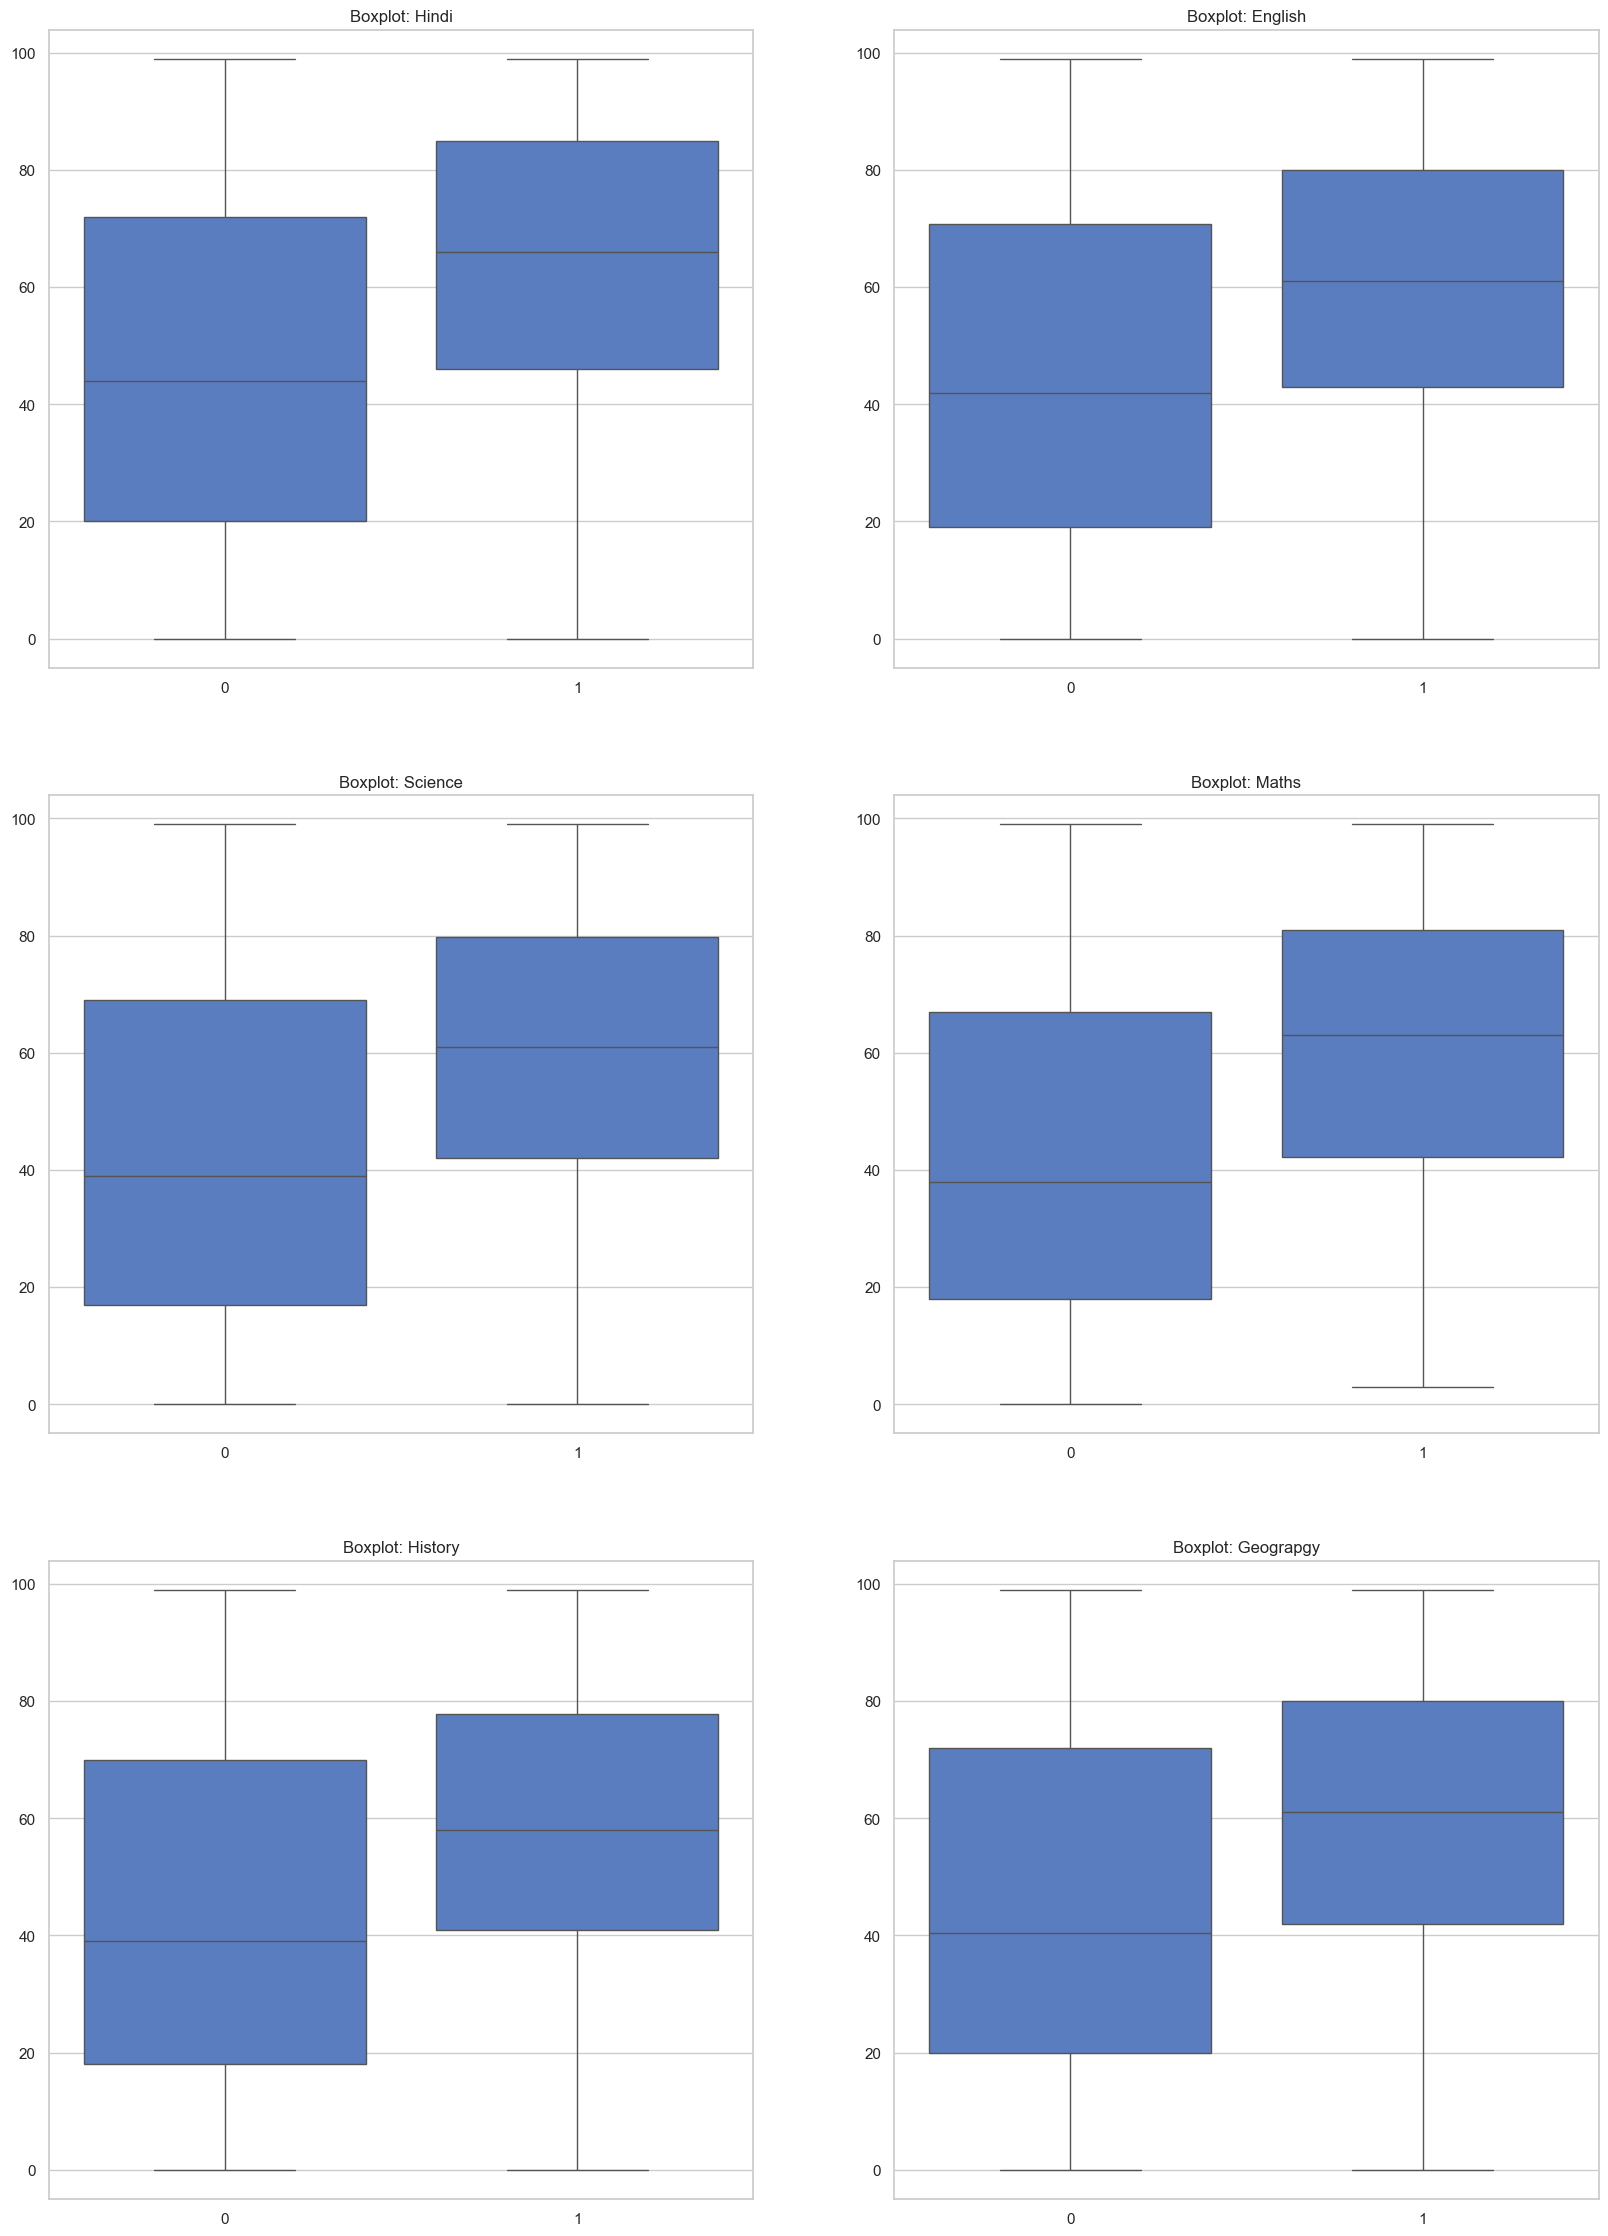

In [45]:
# Comparacion via Boxplot
features = df1.drop("Results", axis=1)

plt.figure(figsize=(20, 58))
gs = gridspec.GridSpec(6, 2)
gs.update(hspace=0.2)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    sns.boxplot(data=df1, x="Results", y=f, ax=ax)
    ax.set_xlabel('')  
    ax.set_ylabel('') 
    ax.set_title(f"Boxplot: {f}")

plt.show()


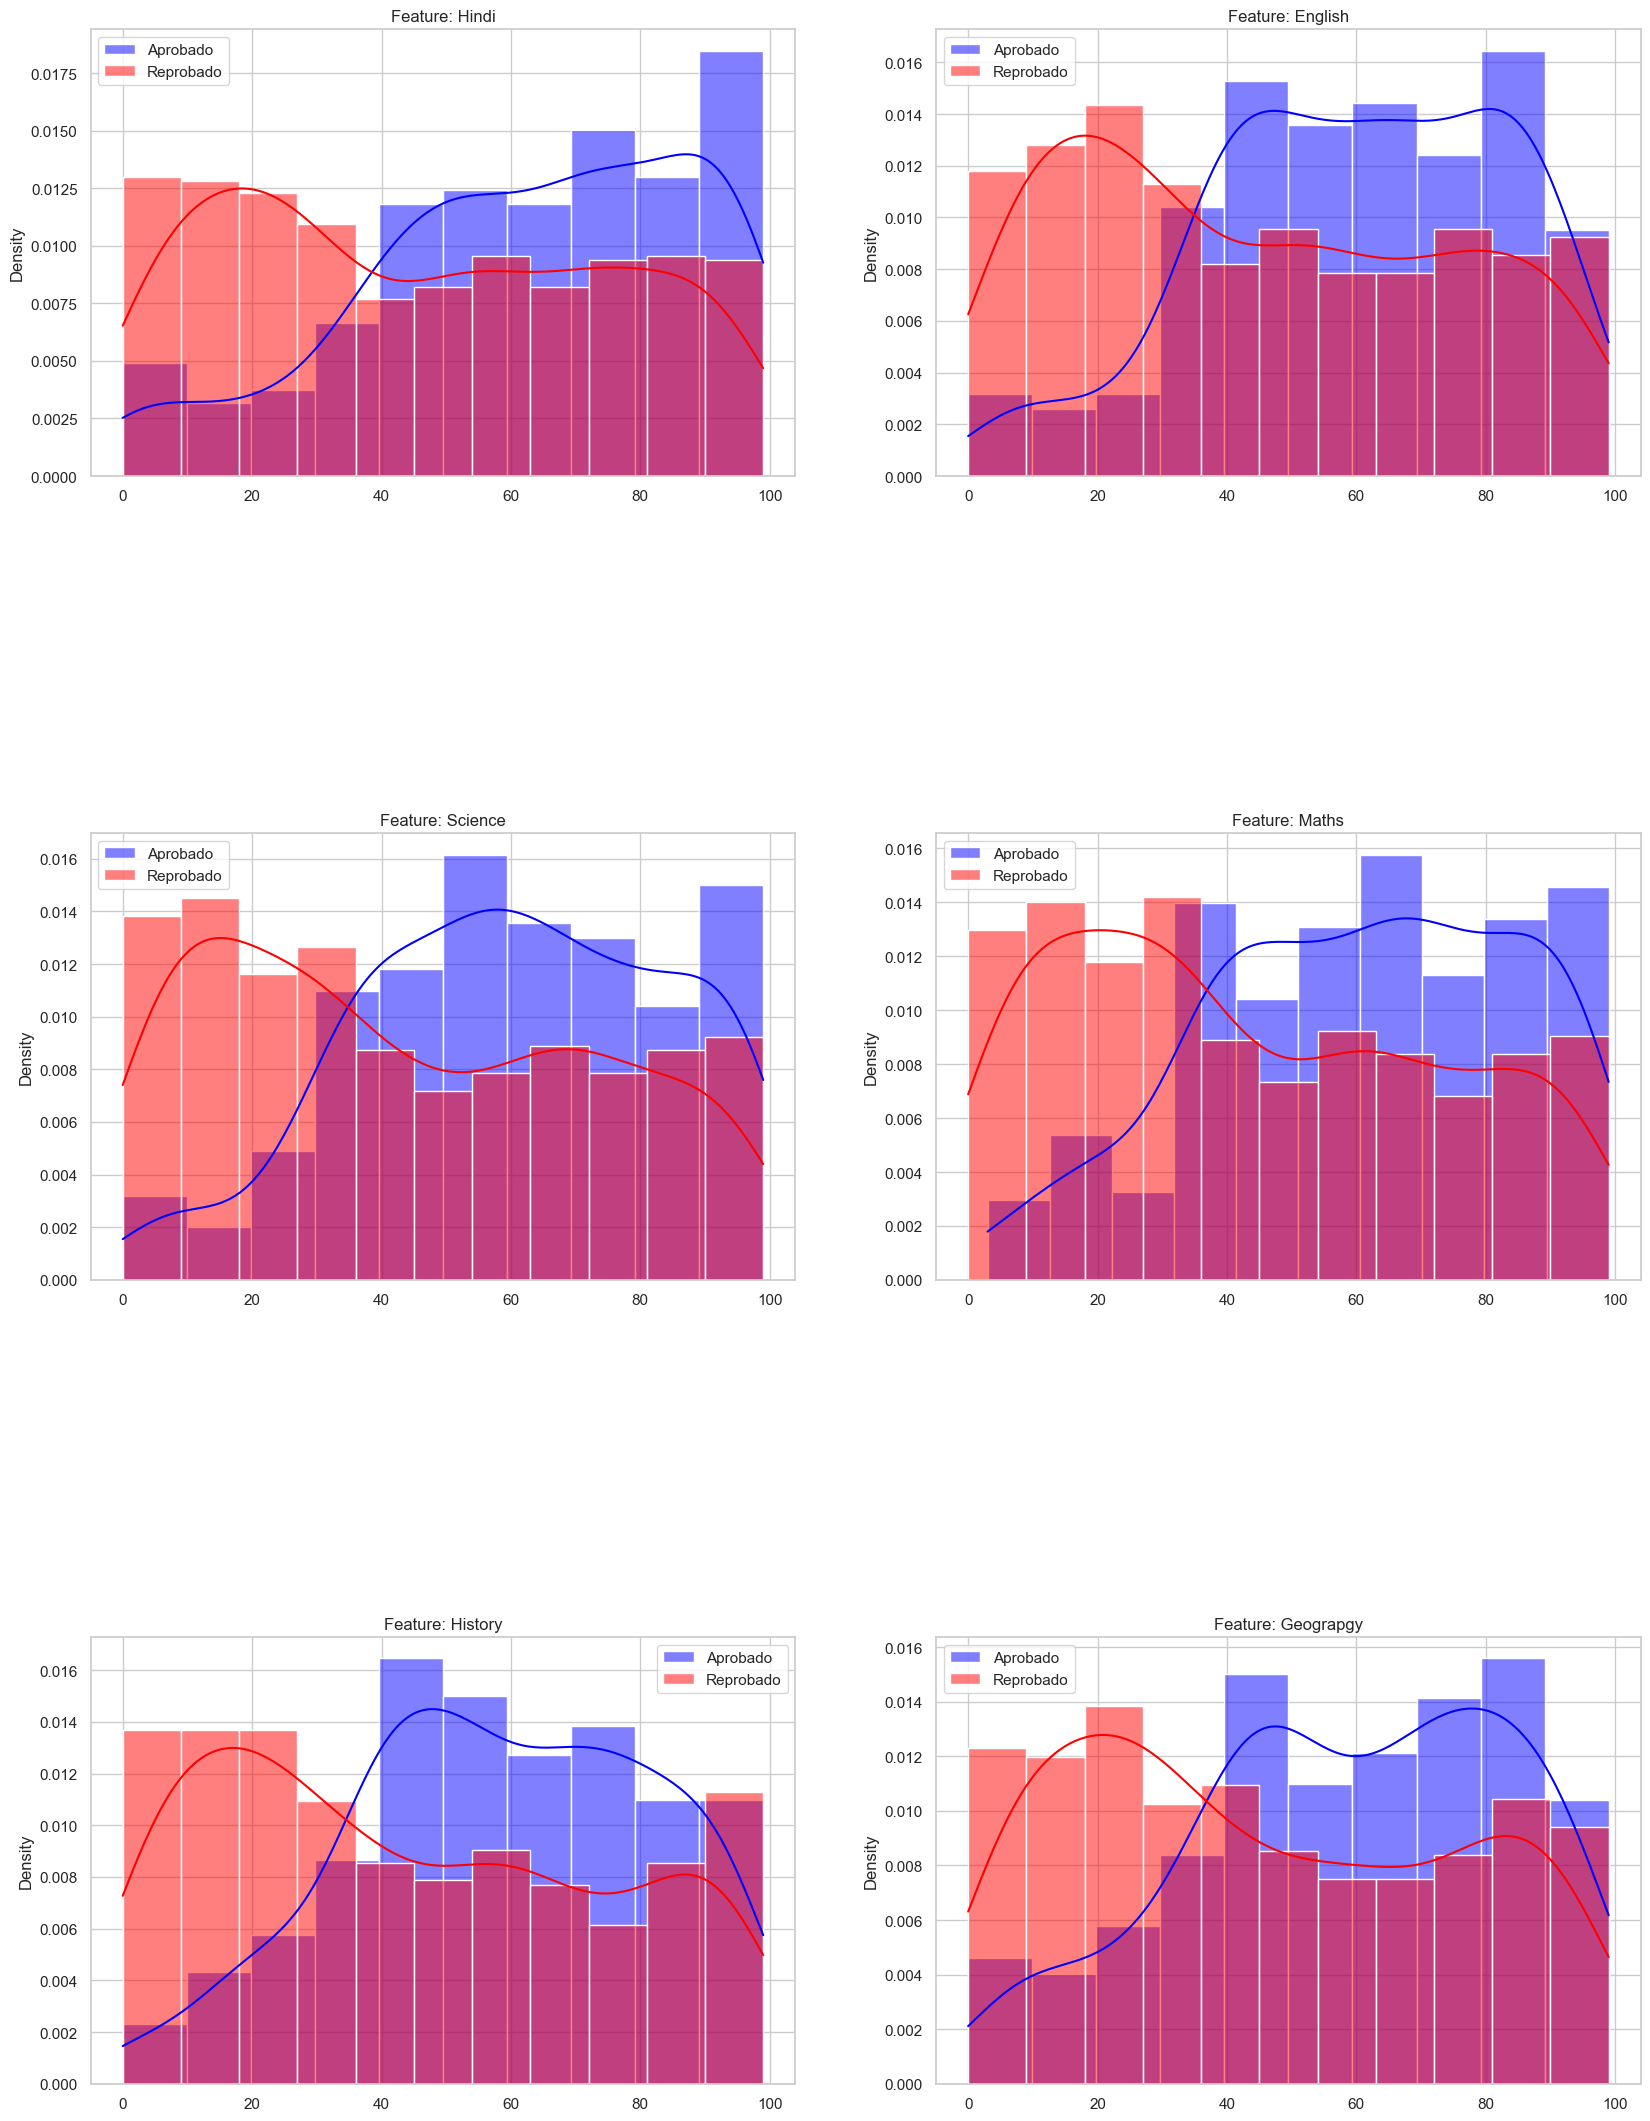

In [47]:
# Comparacion via Densidad
features = df1.drop("Results", axis=1)

plt.figure(figsize=(20, 58))
gs = gridspec.GridSpec(6, 2)
gs.update(hspace=0.8)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    # Usando histplot para los casos donde Results== 1
    sns.histplot(data=df1[df1["Results"] == 1], x=f, kde=True, color="blue", stat="density", label="Aprobado", alpha=0.5)
    # Usando histplot para los casos donde Results == 0
    sns.histplot(data=df1[df1["Results"] == 0], x=f, kde=True, color="red", stat="density", label="Reprobado", alpha=0.5)
    ax.set_xlabel('')
    ax.set_title(f"Feature: {f}")
    ax.legend()

plt.show()

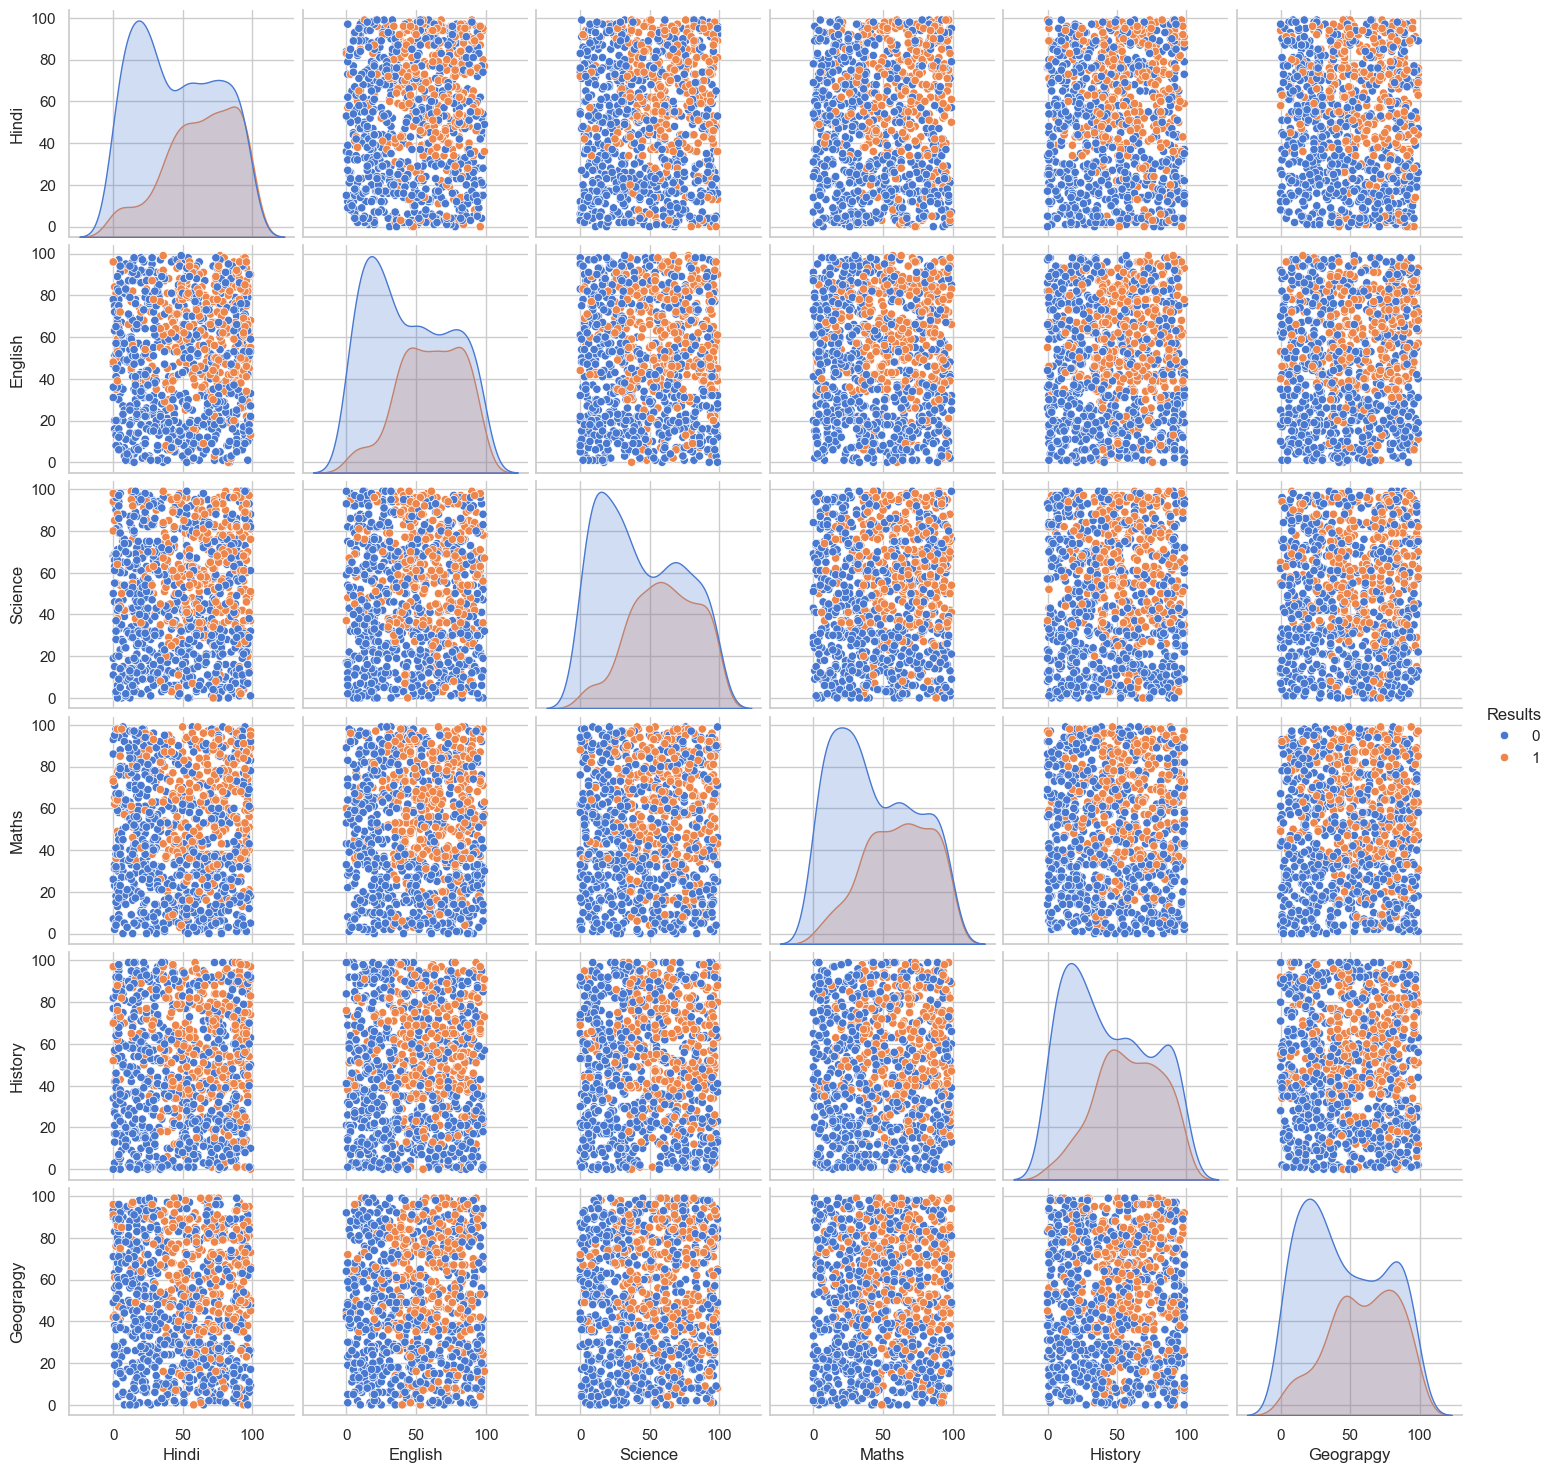

In [15]:
sns.pairplot(df1, hue="Results", vars=df1.columns[:-1])
plt.show()

## 5. Calculo de correlaciones

In [48]:
# Calculamos correlaciones
corr_matrix = df1.corr(method="spearman")
corr_matrix["Results"].sort_values(ascending=False)

Results      1.000000
Maths        0.288128
Science      0.277305
Hindi        0.269868
English      0.252759
History      0.240656
Geograpgy    0.226362
Name: Results, dtype: float64

In [49]:
df1.corr(method="spearman")

,Hindi,English,Science,Maths,History,Geograpgy,Results
Hindi,1.000000,0.036963,0.038720,0.045364,-0.021182,-0.063257,0.269868
English,0.036963,1.000000,-0.023393,-0.013092,-0.001139,0.052349,0.252759
Science,0.038720,-0.023393,1.000000,0.055931,0.005646,0.028465,0.277305
Maths,0.045364,-0.013092,0.055931,1.000000,0.012093,-0.001147,0.288128
History,-0.021182,-0.001139,0.005646,0.012093,1.000000,-0.020919,0.240656
Geograpgy,-0.063257,0.052349,0.028465,-0.001147,-0.020919,1.000000,0.226362
Results,0.269868,0.252759,0.277305,0.288128,0.240656,0.226362,1.000000


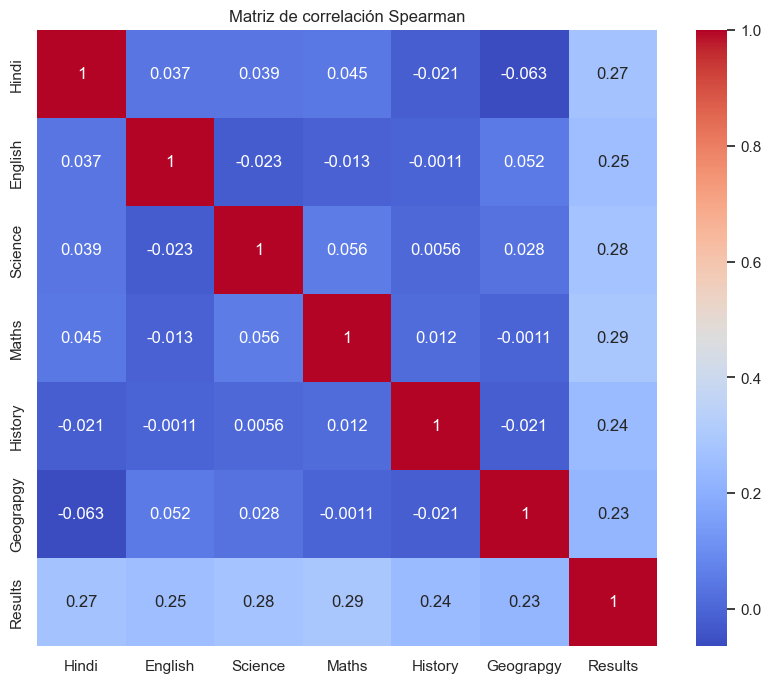

In [50]:
# Heatmap de la matriz de correlacion
corr = df1[df1.columns].corr(method="spearman")
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación Spearman")
plt.show()

In [51]:
# Prueba de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df1)

print(f"Chi-square value: {chi_square_value}")
print(f"P-value: {p_value}")

Chi-square value: 507.25664256964575
P-value: 4.4944085296646496e-94


In [52]:
# Interpretación de la prueba de Bartlett
alpha = 0.05
if p_value < alpha:
    print(f"Rechazar la hipótesis nula: La matriz de correlación es significativamente diferente de una matriz identidad (p < {alpha}).")
    print("El análisis factorial u otras técnicas de reducción de dimensionalidad pueden ser apropiadas.")
else:
    print(f"No se rechaza la hipótesis nula: La matriz de correlación no es significativamente diferente de una matriz identidad (p >= {alpha}).")
    print("El análisis factorial u otras técnicas de reducción de dimensionalidad pueden no ser adecuadas.")

Rechazar la hipótesis nula: La matriz de correlación es significativamente diferente de una matriz identidad (p < 0.05).
El análisis factorial u otras técnicas de reducción de dimensionalidad pueden ser apropiadas.


In [53]:
# Funcion que calcula la matriz de valores p (p-values) correspondientes a las correlaciones de Spearman
def corr_pvalues(df):
    df = df.dropna()
    cols = df.columns
    pmat = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            _, p = spearmanr(df[cols[i]], df[cols[j]])
            pmat.iloc[i, j] = p
    
    return pmat

pval_df = corr_pvalues(df1.drop(columns=["Results"]))

In [54]:
# Funcion que se queda solo con el triangulo inferior de los p-values
def get_lower_triangle(corr):
    lower = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    return lower

lower_corr = get_lower_triangle(corr)
lower_corr

,Hindi,English,Science,Maths,History,Geograpgy,Results
Hindi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
English,0.036963,NaN,NaN,NaN,NaN,NaN,NaN
Science,0.038720,-0.023393,NaN,NaN,NaN,NaN,NaN
Maths,0.045364,-0.013092,0.055931,NaN,NaN,NaN,NaN
History,-0.021182,-0.001139,0.005646,0.012093,NaN,NaN,NaN
Geograpgy,-0.063257,0.052349,0.028465,-0.001147,-0.020919,NaN,NaN
Results,0.269868,0.252759,0.277305,0.288128,0.240656,0.226362,NaN


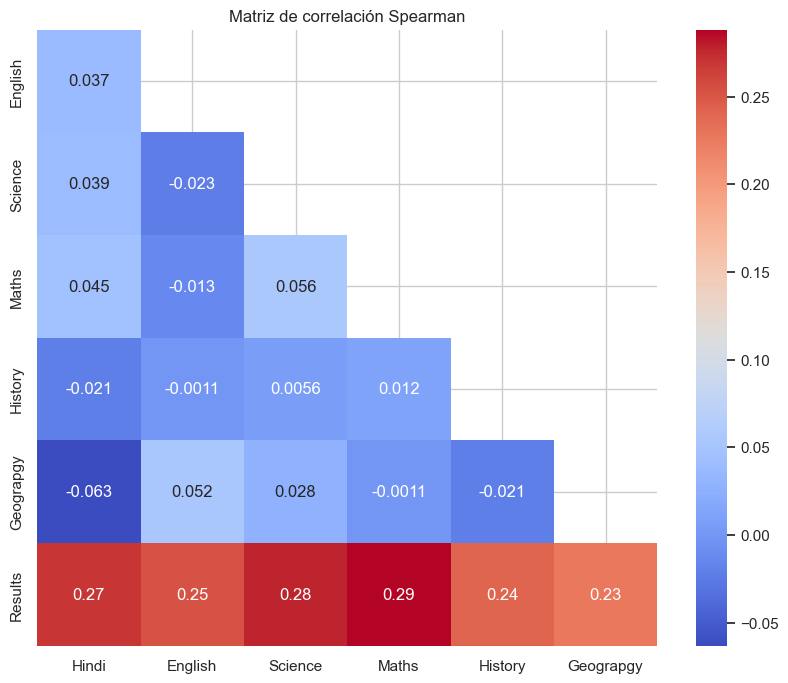

In [55]:
# Representacion grafica de la matriz de correlacion Spearman triangulo inferior
lower_corr1 = lower_corr.drop("Results", axis=1).drop("Hindi", axis=0)

plt.figure(figsize=(10,8))
sns.heatmap(lower_corr1, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación Spearman")
plt.show()

In [56]:
# Escalado del dataframe usando el CustomScalerMinMax
custom_scaler = CustomScalerMinMax(["Hindi",
                                    "English",
                                    "Science",
                                    "Maths",
                                    "History",
                                    "Geograpgy"])
df_scaled = custom_scaler.fit_transform(df1)
df_scaled                               

,Hindi,English,Science,Maths,History,Geograpgy,Results
0,0.656566,0.101010,0.595960,0.030303,0.717172,0.373737,0
1,0.949495,0.565657,0.040404,0.676768,0.919192,0.505051,1
2,0.070707,0.858586,0.767677,1.000000,0.606061,0.252525,0
3,0.888889,0.464646,0.595960,0.949495,0.525253,0.383838,1
4,0.393939,0.818182,0.373737,0.383838,0.060606,0.545455,1
...,...,...,...,...,...,...,...
995,0.555556,0.898990,0.686869,0.585859,0.131313,0.131313,0
996,0.424242,0.626263,0.252525,0.878788,0.515152,0.686869,1
997,0.090909,0.838384,0.707071,0.141414,0.111111,0.787879,0
998,0.232323,0.828283,0.313131,0.424242,0.848485,0.525253,0


## 6. PCA

In [57]:
# Separacion de etiquetas para aplicar PCA
X_df, y_df = remove_labels(df_scaled, "Results")
X_df.head()

,Hindi,English,Science,Maths,History,Geograpgy
0,0.656566,0.101010,0.595960,0.030303,0.717172,0.373737
1,0.949495,0.565657,0.040404,0.676768,0.919192,0.505051
2,0.070707,0.858586,0.767677,1.000000,0.606061,0.252525
3,0.888889,0.464646,0.595960,0.949495,0.525253,0.383838
4,0.393939,0.818182,0.373737,0.383838,0.060606,0.545455


In [58]:
from sklearn.decomposition import PCA

pca = PCA()
df_PCA = pca.fit_transform(X_df)

In [59]:
# Numero de dimensionaes del nuevo conjunto
print("Número de componentes:", pca.n_components_)

Número de componentes: 6


In [60]:
# Calculamos la proporción de varianza que se ha preservado del conjunto original
explained_variance_ratio = (pca.explained_variance_ratio_)*100
explained_variance_ratio

array([18.68553281, 17.58129441, 17.19185571, 16.39233051, 15.69256183,
       14.45642473])

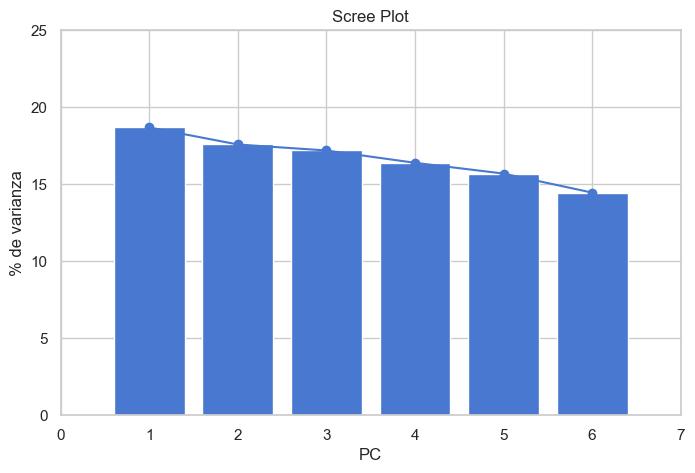

In [61]:
# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='-')
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.title('Scree Plot')
plt.xlabel('PC')
plt.xlim(0, 7)
plt.ylabel('% de varianza')
plt.ylim(0, 25)
plt.show()

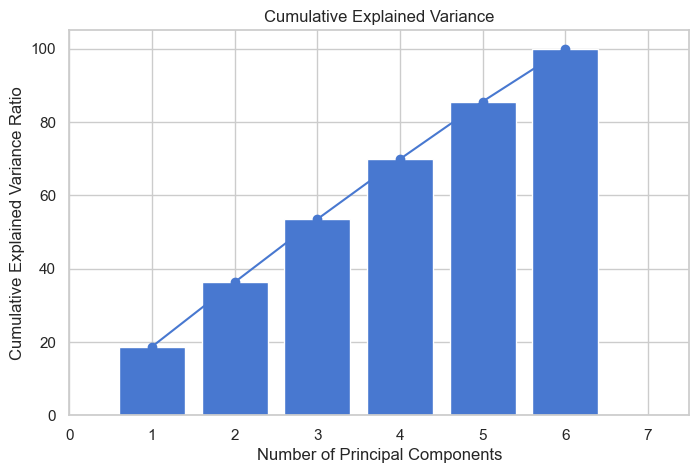

In [62]:
# Grafico de la varianza acumulada
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')
plt.bar(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance)
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.xlim(0, 7.5)
plt.ylabel('Cumulative Explained Variance Ratio')
plt.ylim(0, )
plt.grid(True)
plt.show()

In [63]:
# Transformamos a un DataFrame de Pandas
df_PCA = pd.DataFrame(df_PCA, columns=["PCA1", "PCA2", "PCA3", "PCA4", "PCA5", "PCA6"])
df_PCA["Results"] = y_df
df_PCA.head()

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,Results
0,-0.022286,-0.250419,0.256710,-0.121254,-0.506926,-0.280275,0
1,0.195077,-0.334321,0.080013,0.507128,0.268362,-0.350104,1
2,0.043711,0.317259,0.305927,0.111070,0.311238,0.647942,0
3,0.539453,0.041396,0.081771,0.037058,0.242885,-0.057865,1
4,-0.190717,-0.040086,-0.460854,-0.104638,0.077118,0.257640,1


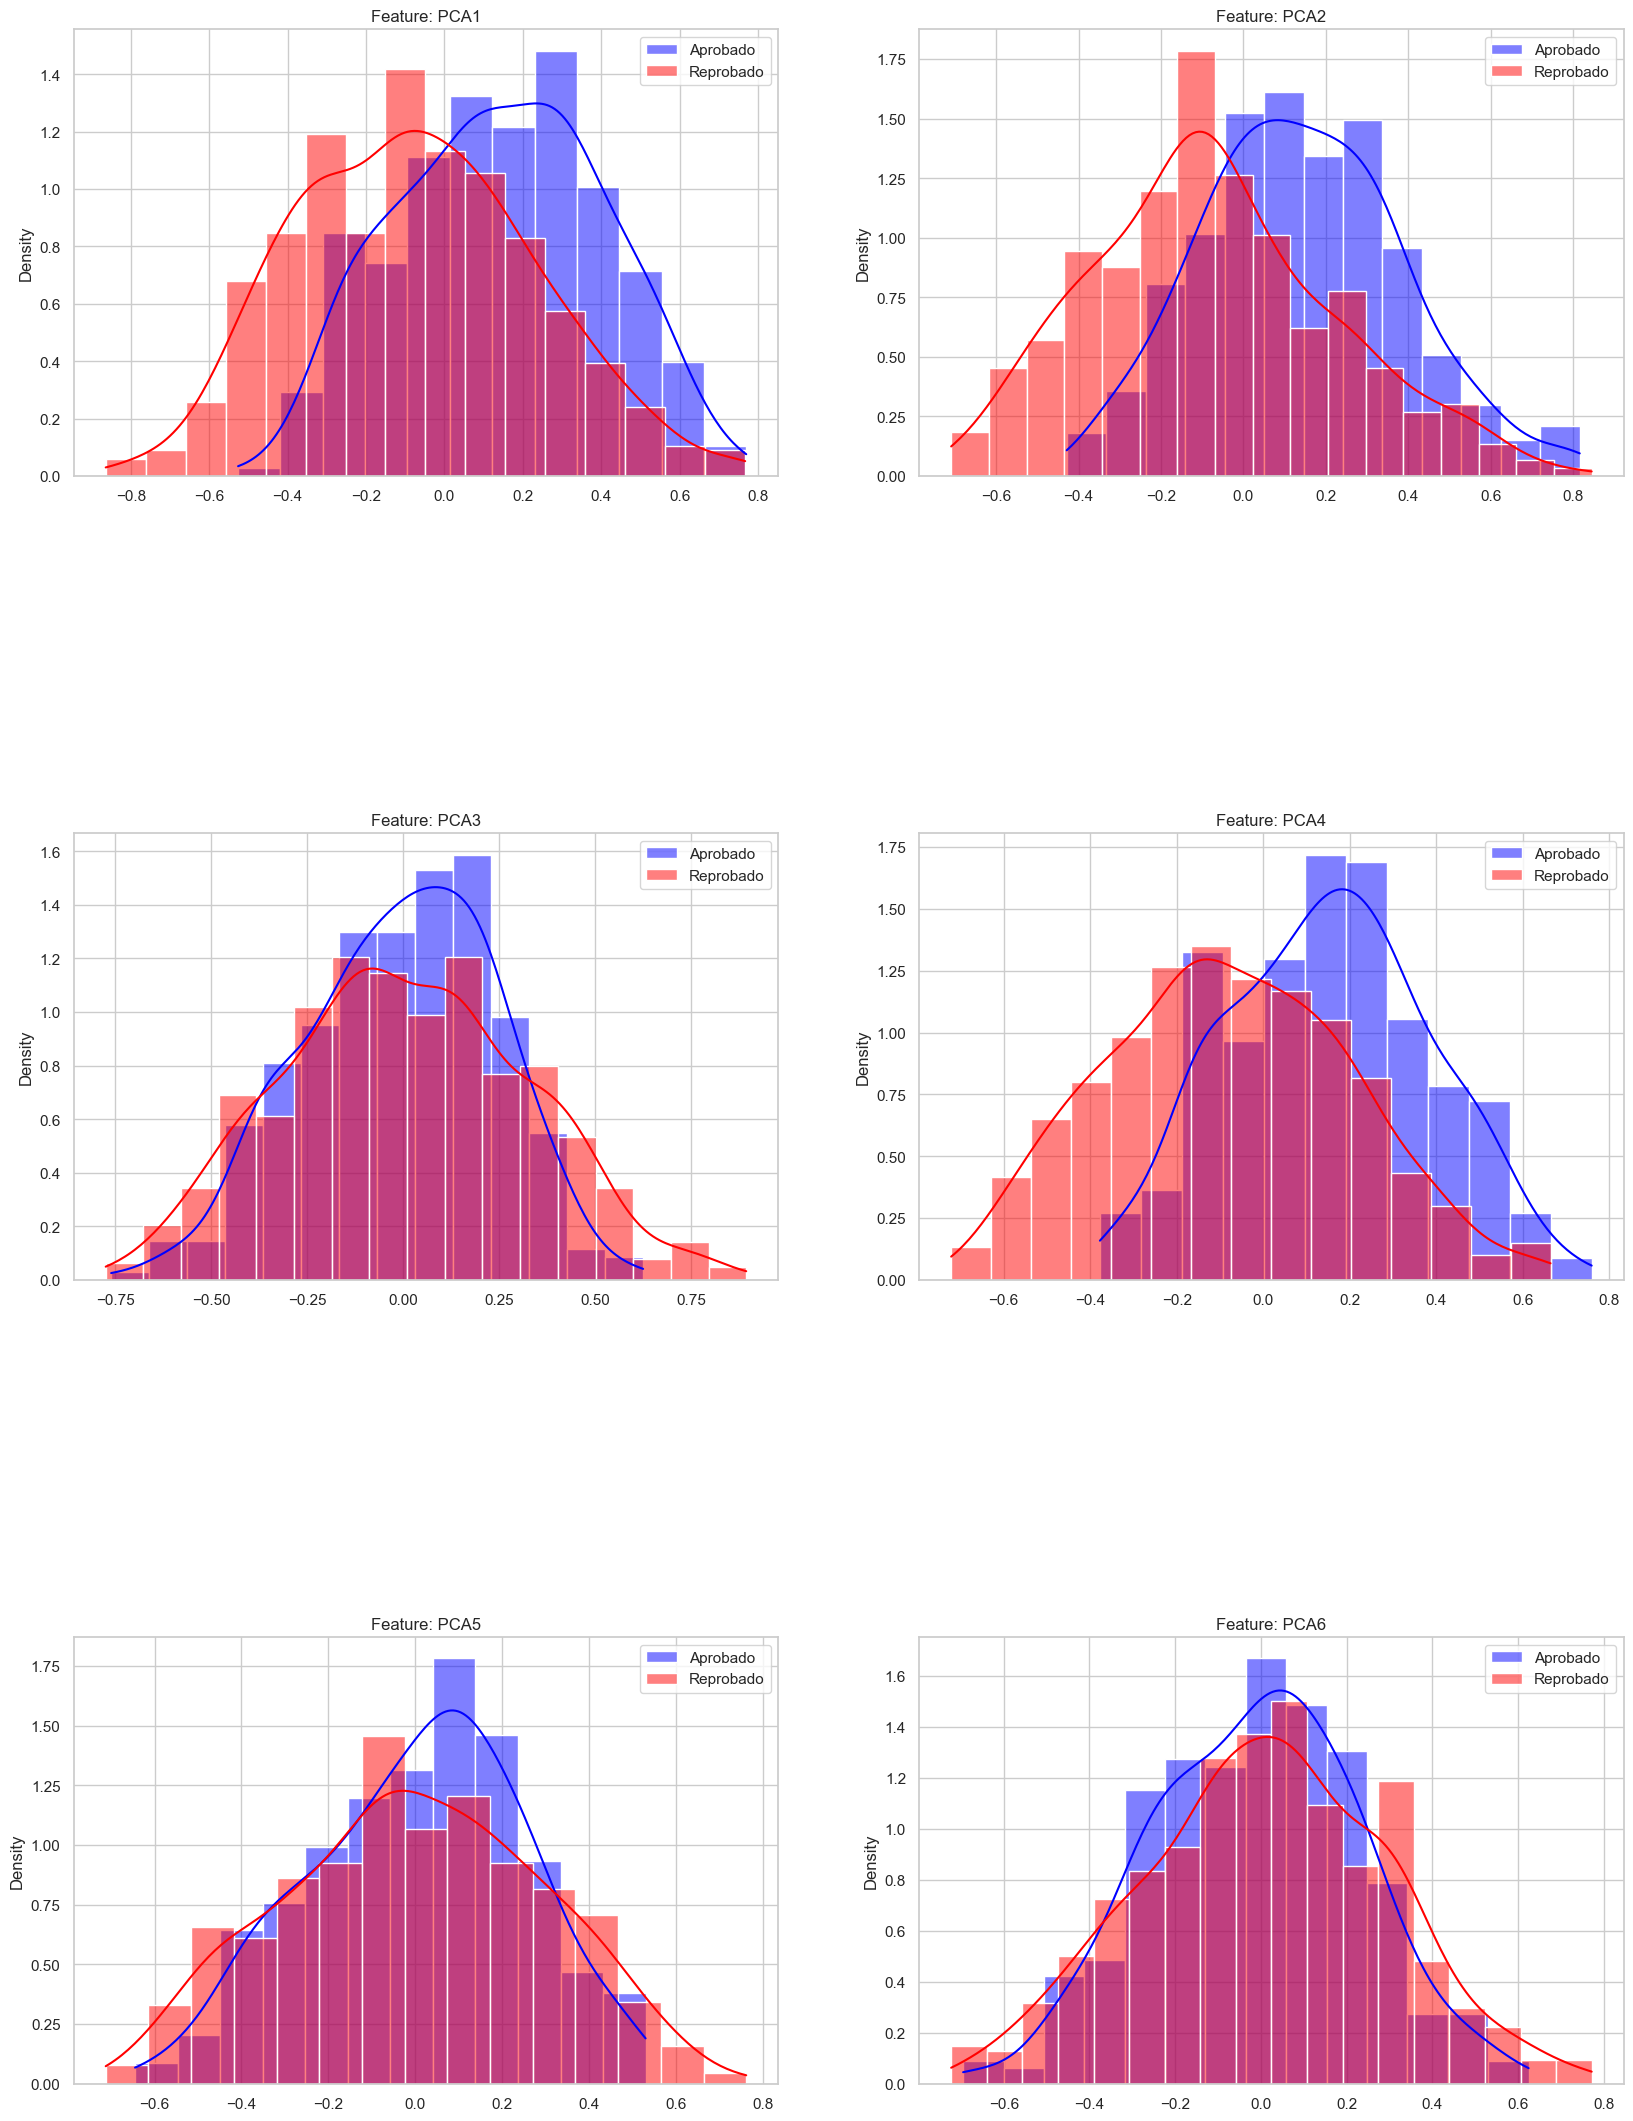

In [64]:
# Representamos gráficamente las características
features = df_PCA.drop("Results", axis=1)

plt.figure(figsize=(20, 58))
gs = gridspec.GridSpec(6, 2)
gs.update(hspace=0.8)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    # Usando histplot para los casos donde Results == 1
    sns.histplot(data=df_PCA[df_PCA["Results"] == 1], x=f, kde=True, color="blue", stat="density", label="Aprobado", alpha=0.5)
    # Usando histplot para los casos donde Results == 0
    sns.histplot(data=df_PCA[df_PCA["Results"] == 0], x=f, kde=True, color="red", stat="density", label="Reprobado", alpha=0.5)
    ax.set_xlabel('')
    ax.set_title(f"Feature: {f}")
    ax.legend()

plt.show()

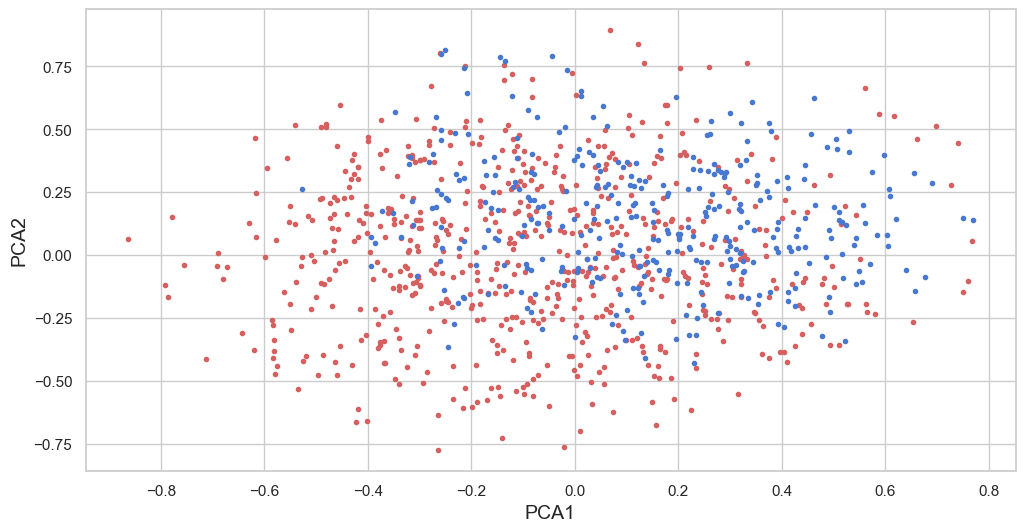

In [65]:
# Representación gráfica de dos características
plt.figure(figsize=(12, 6))
plt.scatter(df_PCA["PCA1"][df_PCA['Results'] == 0], df_PCA["PCA3"][df_PCA['Results'] == 0], c="r", marker=".")
plt.scatter(df_PCA["PCA1"][df_PCA['Results'] == 1], df_PCA["PCA2"][df_PCA['Results'] == 1], c="b", marker=".")
plt.xlabel("PCA1", fontsize=14)
plt.ylabel("PCA2", fontsize=14)
plt.show()